# SIR Model for Influenza-Like Illness (ILI)
## Python Translation of Section 8.6

We reproduce the parameter estimation workflow using Python:

• Load CDC ILINet data  
• Deterministic SIR model  
• Least-squares estimation  
• General optimization  
• Maximum likelihood estimation

Assumption used:
ILI(t) ≈ Infectious compartment I(t)

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from scipy.integrate import solve_ivp

import pandas as pd

df = pd.read_csv("ILINet.csv", sep=",")

df.head()

,REGION TYPE,REGION,YEAR,WEEK,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 25-49,AGE 25-64,AGE 5-24,AGE 50-64,AGE 65,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS
0,Census Regions,New England,1997,40,0.498535,0.623848,15,X,7,22,X,0,44,32,7053
1,Census Regions,Mid-Atlantic,1997,40,0.844144,1.321380,4,X,8,12,X,4,28,13,2119
2,Census Regions,East North Central,1997,40,0.792486,0.818738,28,X,20,28,X,3,79,47,9649
3,Census Regions,West North Central,1997,40,1.764050,1.279390,3,X,8,20,X,6,37,17,2892
4,Census Regions,South Atlantic,1997,40,0.502662,0.723380,14,X,22,14,X,0,50,30,6912


**These are weekly counts of outpatient ILI visits.**

Theory link

This is the observed process:

**Y_t  =ILI counts**

In [ ]:
df.replace("X", np.nan, inplace=True)
df.head()

,REGION TYPE,REGION,YEAR,WEEK,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 25-49,AGE 25-64,AGE 5-24,AGE 50-64,AGE 65,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS
0,Census Regions,New England,1997,40,0.498535,0.623848,15,NaN,7,22,NaN,0,44,32,7053
1,Census Regions,Mid-Atlantic,1997,40,0.844144,1.321380,4,NaN,8,12,NaN,4,28,13,2119
2,Census Regions,East North Central,1997,40,0.792486,0.818738,28,NaN,20,28,NaN,3,79,47,9649
3,Census Regions,West North Central,1997,40,1.764050,1.279390,3,NaN,8,20,NaN,6,37,17,2892
4,Census Regions,South Atlantic,1997,40,0.502662,0.723380,14,NaN,22,14,NaN,0,50,30,6912


In [ ]:
ili_data = df[["REGION", "WEEK", "ILITOTAL"]]

ili_data.head()

,REGION,WEEK,ILITOTAL
0,New England,40,44
1,Mid-Atlantic,40,28
2,East North Central,40,79
3,West North Central,40,37
4,South Atlantic,40,50


**CDC flu season 2016 = year 2016 weeks 1-24**

In [ ]:
ili_data = ili_data[
    (df["YEAR"] == 2016) &
    (ili_data["WEEK"] > 0) &
    (ili_data["WEEK"] < 25) &
    (ili_data["REGION"].isin(["Mid-Atlantic","New England","Pacific"]))
]
ili_data.head()

/tmp/ipython-input-2493425884.py:1: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



,REGION,WEEK,ILITOTAL
8577,New England,1,455
8578,Mid-Atlantic,1,3165
8585,Pacific,1,1190
8586,New England,2,491
8587,Mid-Atlantic,2,3101



**“Patients suffering from ILI for weeks 1-24 of CDC flu season (is Oct-May) 2016”**

Why year 2016?

Because:

Flu season 2015-2016
→ early weeks lie in calendar year 2016.


In [ ]:
fig = go.Figure()

def add_region(region, dash=None, color=None):
    d = ili_data[ili_data["REGION"]==region]
    fig.add_trace(go.Scatter(
        x=d["WEEK"],
        y=d["ILITOTAL"],
        mode="lines",
        name=region,
        line=dict(dash=dash, color=color)
    ))

add_region("Mid-Atlantic","dash","#b2182b")
add_region("New England","dot","#2166ac")
add_region("Pacific",None,"#fddbc7")

fig.update_layout(xaxis_title="week", yaxis_title="ilitotal")
fig.show()


The above plot:

ILITOTAL vs week for three regions.


This visualizes epidemic curves: Iobs(t).

**Next, define differential equations.
This is the process model.**

In [ ]:
def sir_rhs(t, y, beta, gamma, N):
    S, I, R = y
    dS = -beta*S*I/N
    dI = beta*S*I/N - gamma*I
    dR = gamma*I
    return [dS,dI,dR]


**You simulate, (S(t),I(t),R(t)) numerically.**


In [ ]:
def trajectory(beta, gamma, N, S0, I0, weeks):
    y0 = [S0, I0, N-S0-I0]

    sol = solve_ivp(
        sir_rhs,
        [weeks.min(), weeks.max()],
        y0,
        t_eval=weeks,
        args=(beta,gamma,N)
    )

    return sol.y[1]  # infectious trajectory


**You generate predicted infections: Imodel(t;β,γ).**

We fit SIR to ONE region.

In [ ]:
ne_data = ili_data[ili_data["REGION"]=="New England"]

weeks = ne_data["WEEK"].values
obs_I = ne_data["ILITOTAL"].values



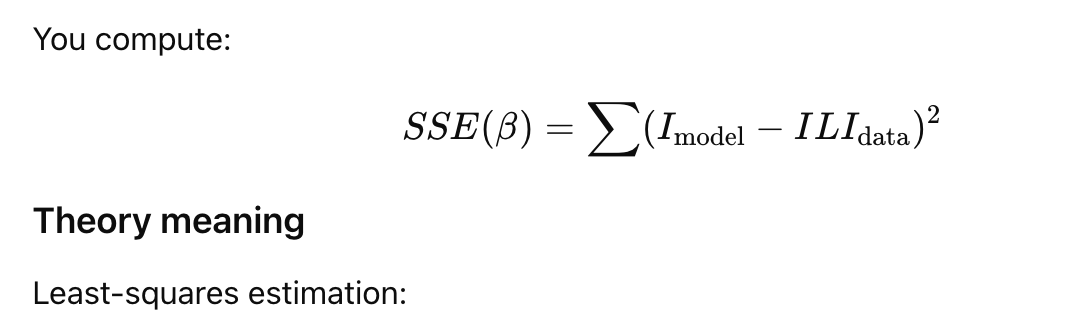

**Find β that minimizes distance between model and data.**
Key assumption:
**ILI(t)≈I(t)**

In [ ]:
def sse(beta):
    gamma = 1       # assumption
    N = 14000000
    S0 = 50000
    I0 = 450

    I_model = trajectory(beta,gamma,N,S0,I0,weeks)

    return np.sum((I_model - obs_I)**2)


**Grid search for β**
Testing many β values.

For each β:

- simulate SIR

- compute SSE

In [ ]:
beta_grid = np.linspace(0,500,100)
SSE = np.array([sse(b) for b in beta_grid])


In [ ]:
fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=beta_grid,y=SSE,mode="lines"))
fig2.update_layout(xaxis_title="beta", yaxis_title="SSE")
fig2.show()

In [ ]:
beta_hat1 = beta_grid[np.argmin(SSE)]
beta_hat1

np.float64(323.2323232323232)

In [ ]:
gamma = 1
N = 14000000
S0 = 50000
I0 = 450

I_fit_grid = trajectory(beta_hat1, gamma, N, S0, I0, weeks)

In [ ]:
sir_grid_fit_df = ne_data.copy()
sir_grid_fit_df["I_fit"] = I_fit_grid

In [ ]:
fig3 = go.Figure()

fig3.add_trace(go.Scatter(
    x=sir_grid_fit_df["WEEK"],
    y=sir_grid_fit_df["ILITOTAL"],
    mode="lines",
    name="data"
))

fig3.add_trace(go.Scatter(
    x=sir_grid_fit_df["WEEK"],
    y=sir_grid_fit_df["I_fit"],
    mode="lines",
    line=dict(dash="dash"),
    name="fitted"
))

fig3.update_layout(xaxis_title="week", yaxis_title="I(t)")
fig3.show()


In [ ]:
def sse_full(beta, gamma, I0):
    N = 14000000
    S0 = 50000

    I_model = trajectory(beta, gamma, N, S0, I0, weeks)
    return np.sum((I_model - obs_I)**2)


In [ ]:
def objective(par):
    beta, gamma, I0 = par
    return sse_full(beta, gamma, I0)

In [ ]:
from scipy.optimize import minimize

init_guess = [320, 1, 450]

fit2 = minimize(objective, init_guess, method="Nelder-Mead")

fit2

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 131485.5278690175
             x: [ 3.620e+02  1.103e+00  3.703e+02]
           nit: 153
          nfev: 288
 final_simplex: (array([[ 3.620e+02,  1.103e+00,  3.703e+02],
                       [ 3.620e+02,  1.103e+00,  3.703e+02],
                       [ 3.620e+02,  1.103e+00,  3.703e+02],
                       [ 3.620e+02,  1.103e+00,  3.703e+02]]), array([ 1.315e+05,  1.315e+05,  1.315e+05,  1.315e+05]))

In [ ]:
beta_hat2, gamma_hat2, I0_hat2 = fit2.x

beta_hat2, gamma_hat2, I0_hat2



(np.float64(362.0237477491197),
 np.float64(1.1034407058579507),
 np.float64(370.26969716425197))

In [ ]:
I_fit_optim = trajectory(beta_hat2, gamma_hat2, N, S0, I0_hat2, weeks)


In [ ]:
sir_optim_fit_df = ne_data.copy()
sir_optim_fit_df["I_fit"] = I_fit_optim


In [ ]:
fig4 = go.Figure()

fig4.add_trace(go.Scatter(
    x=sir_optim_fit_df["WEEK"],
    y=sir_optim_fit_df["ILITOTAL"],
    mode="lines",
    name="data"
))

fig4.add_trace(go.Scatter(
    x=sir_optim_fit_df["WEEK"],
    y=sir_optim_fit_df["I_fit"],
    mode="lines",
    line=dict(dash="dash"),
    name="fitted"
))

fig4.update_layout(xaxis_title="week", yaxis_title="I(t)")
fig4.show()


Define b = β/N

Observation model:
ILI ~ Normal(mean = I_model, sd = σ)

logL = Σ log Normal(obs | I_model, σ)

This function is a Log-Likelihood scorer for your SIR model. It calculates one single number that represents how well a specific transmission rate (b) fits your real-world data (obs_I).


In [ ]:
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from scipy.stats import norm
import plotly.graph_objects as go

def loglik(b,gamma=1,sigma=1):
    beta = b*14000000
    I_model = trajectory(beta,gamma,14000000,50000,450,weeks) #trajectory(beta,gamma,N,S0,I0,weeks)
    return np.sum(norm.logpdf(obs_I,loc=I_model,scale=sigma))


- The Result: You get a single "best fit" point estimate.
- **The Logic:** "Out of all possible SIR curves, this specific curve is the most likely to have produced the data I observed."


In [ ]:
b_vals = np.linspace(200/14000000,400/14000000,100)
ll = np.array([loglik(b) for b in b_vals])


In [ ]:
fig4 = go.Figure()
fig4.add_trace(go.Scatter(x=b_vals,y=ll,mode="lines"))
fig4.update_layout(yaxis_title="log(L)",xaxis_title="b")
fig4.show()

In [ ]:
b_hat = b_vals[np.argmax(ll)]
beta_hat_mle = b_hat*14000000

I_fit_mle = trajectory(beta_hat_mle,1,14000000,50000,450,weeks)

fig5 = go.Figure()
fig5.add_trace(go.Scatter(x=weeks,y=obs_I,mode="lines",name="data"))
fig5.add_trace(go.Scatter(x=weeks,y=I_fit_mle,mode="lines",
                          line=dict(dash="dash"),name="fitted"))
fig5.show()

We define **b=β/N**

because:

-  The model only depends on β through β/N
-  MLE prefers parameters with natural scale
-  Optimization becomes numerically stable
-  Likelihood surface becomes smoother

Nothing physical changes, just a smarter parameterization.

We divide by N because infection depends on the probability of meeting an infected person, which is, **I/N**, not simply the number of infected individuals.

- 10 infected in population of 100

vs

- 10 infected in population of 1,000,000

The risk to a susceptible should be MUCH lower in the large population.

Dividing by N ensures that.
